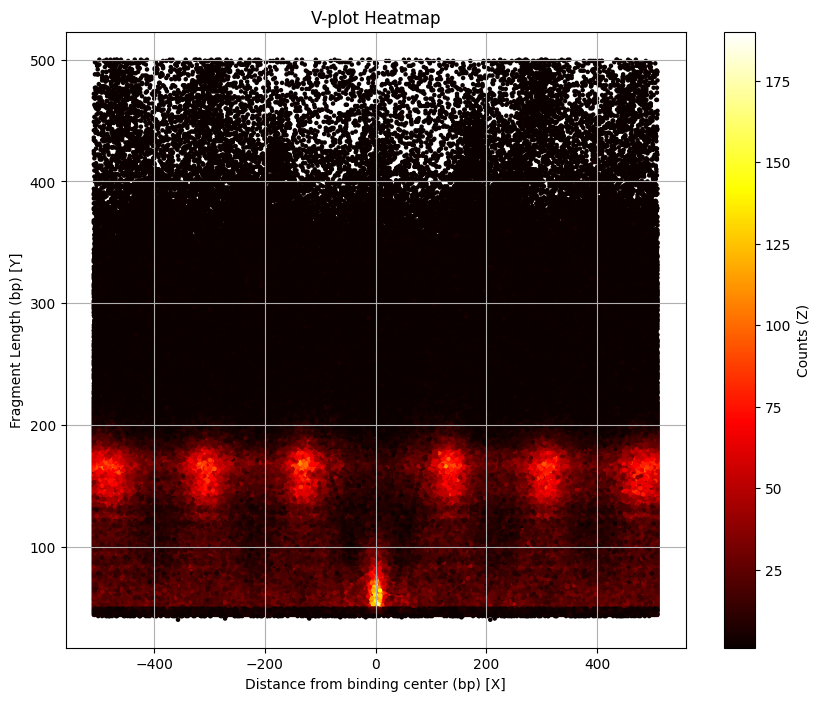

In [1]:
import gzip
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from collections import defaultdict
counts = defaultdict(int)
with gzip.open('mapped.bed.gz', 'rt') as f:
    for line in f:
        if line.strip() == "":
            continue
        parts = line.strip().split('\t')
        if len(parts) < 11:
            continue
        start_binding = int(parts[2])
        end_binding = int(parts[3])
        start_fragment = int(parts[8])
        end_fragment = int(parts[9])
        c1 = (start_binding + end_binding) // 2
        c2 = (start_fragment + end_fragment) // 2
        x = c2 - c1
        y = end_fragment - start_fragment
        counts[(x, y)] += 1
X, Y, Z = zip(*[(x, y, z) for (x, y), z in counts.items()])

plt.figure(figsize=(10, 8))
plt.scatter(X, Y, c=Z, cmap='hot', s=5)
plt.colorbar(label='Counts (Z)')
plt.xlabel('Distance from binding center (bp) [X]')
plt.ylabel('Fragment Length (bp) [Y]')
plt.title('V-plot Heatmap')
plt.grid(True)
plt.show()
